# Supervised Classification with a Born-Machine MPS

We extend the MPS Born machine to **supervised classification** by appending
a dedicated label site to the path chain.

The joint MPS models `p(xi, y)` where `y ∈ {1, …, C}` is the class label.
Classification uses the **Born rule**:

$$p(y = c \mid \xi) \propto |\Psi(\xi_1, \ldots, \xi_M, c)|^2$$

The label site sits at the **end** of the chain (easiest integration); other
positions are explored in the notes.

### What we compare
- MPS Born classifier
- Logistic regression baseline

In [10]:
import Pkg
Pkg.activate(joinpath(@__DIR__, "../.."))
Pkg.resolve()
Pkg.instantiate()

using MPSFast
using MPSFast.Encoders
using Random, LinearAlgebra, Statistics, Printf
using Plots

  Activating project at `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl`
     Project No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Project.toml`
    Manifest No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Manifest.toml`


## 1. Synthetic Dataset

Two classes: cumulative sums of ±1 random walks with different drift.
- Class 1: positive drift → path tends to rise.
- Class 2: negative drift → path tends to fall.

In [11]:
function synthetic_paths_labels(N, M; drift=0.15, σ=1.0, rng=Random.default_rng())
    paths  = Matrix{Float64}(undef, N, M)
    labels = Vector{Int}(undef, N)
    for i in 1:N
        y = rand(rng, 1:2)
        d = y == 1 ? drift : -drift
        s = cumsum(d .+ σ .* randn(rng, M))
        paths[i,  :] = s
        labels[i]    = y
    end
    return paths, labels
end

rng = MersenneTwister(42)
N_train, N_test, M = 2_000, 500, 15

train_paths, train_labels = synthetic_paths_labels(N_train, M; rng=rng)
test_paths,  test_labels  = synthetic_paths_labels(N_test,  M; rng=rng)

println("Train size: ", size(train_paths), "  class balance: ",
        count(==(1), train_labels), " / ", count(==(2), train_labels))
println("Test size : ", size(test_paths))

Train size: (2000, 15)  class balance: 972 / 1028
Test size : (500, 15)


## 2. Encode Labeled Paths

In [12]:
enc = BasisEncoder(3)   # d = 8 buckets
fit_grid!(enc, train_paths)

xi_train = encode_labeled_paths(enc, train_paths, train_labels; n_classes=2)
xi_test  = encode_labeled_paths(enc, test_paths,  test_labels;  n_classes=2)

Ml_class = classification_chain_length(enc, M)
d_class  = site_dim(enc)
n_classes = 2

println("Joint chain length  : ", Ml_class,  " (path sites + 1 label site)")
println("xi_train shape      : ", size(xi_train))
println("Label site values   : ", sort(unique(xi_train[:, end])))

Joint chain length  : 16 (path sites + 1 label site)
xi_train shape      : (2000, 16)
Label site values   : [1, 2]


## 3. Initialise Joint MPS

The label site has physical dimension `n_classes = 2`. We use a uniform
physical dimension `max(d_class, n_classes)` across all sites for simplicity
(the last site naturally uses only 1:n_classes).

In [13]:
D_max = 32

# Build MPS with label site of dim n_classes at the end
function init_mps_classification(Ml, d_path, n_classes, D_max; rng=Random.default_rng())
    T = Float32
    Ds = [1; [min(d_path^j, D_max) for j in 1:Ml-1]; 1]
    mps = [randn(rng, T, Ds[j], d_path, Ds[j+1]) for j in 1:Ml-1]
    # Last site: physical dim = n_classes
    push!(mps, randn(rng, T, Ds[Ml], n_classes, 1))
    left_canonicalize_mps!(mps)
    return mps
end

mps = init_mps_classification(Ml_class, d_class, n_classes, D_max; rng=MersenneTwister(1))
println("Joint MPS shapes: ", [size(mps[j]) for j in 1:Ml_class])

Joint MPS shapes: [(1, 8, 8), (8, 8, 32), (32, 8, 32), (32, 8, 32), (32, 8, 32), (32, 8, 32), (32, 8, 32), (32, 8, 32), (32, 8, 32), (32, 8, 32), (32, 8, 32), (32, 8, 32), (32, 8, 32), (32, 8, 32), (32, 8, 32), (32, 2, 1)]


## 4. Train Joint Born Machine

In [14]:
n_epochs = 100
η        = 5e-4
ε_cut    = 1e-5

val_nll_log = Float64[]
nll_hist = train_mps!(
    mps, xi_train, n_epochs, η, D_max, ε_cut;
    verbose      = true,
    nll_samples  = 500,
    lr_schedule  = cosine_lr,
    val_data     = xi_test,
    val_samples  = size(xi_test, 1),
    patience     = 10,
    val_nll_log  = val_nll_log,
)

train_mps!: Ml=16, Nd=2000, d=8, D_max=32, epochs=100, one-hot
— Epoch 1/100 —
  ↳ norm envs ready → forward sweep (15 bonds) …
  ↳ forward done → canonicalize + rebuild envs + backward sweep …
  ↳ backward done → canonicalize + NLL estimate …
Epoch 1/100 | NLL ≈ 20.0868 | η=0.0005 | bonds=[8,32,32,32,32,32,32,32,32,32,32,32,32,16,2] | 0.156 s
  ↳ val NLL ≈ 20.5639  (patience 0/10)
— Epoch 2/100 —
  ↳ norm envs ready → forward sweep (15 bonds) …
  ↳ forward done → canonicalize + rebuild envs + backward sweep …
  ↳ backward done → canonicalize + NLL estimate …
Epoch 2/100 | NLL ≈ 17.1116 | η=0.0005 | bonds=[8,32,32,32,32,32,32,32,32,32,32,32,32,16,2] | 0.101 s
  ↳ val NLL ≈ 17.5312  (patience 0/10)
— Epoch 3/100 —
  ↳ norm envs ready → forward sweep (15 bonds) …
  ↳ forward done → canonicalize + rebuild envs + backward sweep …
  ↳ backward done → canonicalize + NLL estimate …
Epoch 3/100 | NLL ≈ 15.447 | η=0.0005 | bonds=[8,32,32,32,32,32,32,32,32,32,32,32,32,16,2] | 0.105 s
  ↳ val NLL

100-element Vector{Float64}:
 20.08676598948701
 17.11158264558703
 15.446958156916551
 14.508665064088401
 13.671651378501512
 13.031262827504309
 12.62059347207442
 12.397101412851294
 12.213902962462857
 11.573856853438684
  ⋮
  7.676005027737359
  7.566200482068832
  7.744355081640462
  7.638216212549305
  7.776436415058058
  7.628982835765447
  7.672633915117247
  7.711891847309068
  7.63263119162611

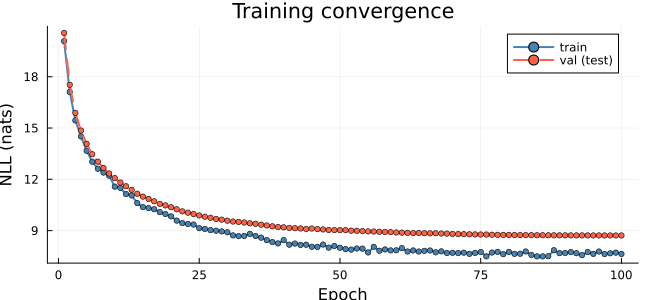

In [15]:
n_done = length(nll_hist)
p_nll = plot(1:n_done, nll_hist;
    lw=2, marker=:circle, ms=3, color=:steelblue, label="train",
    xlabel="Epoch", ylabel="NLL (nats)",
    title="Training convergence", size=(650, 300), legend=:topright)
if !isempty(val_nll_log)
    plot!(p_nll, 1:length(val_nll_log), val_nll_log;
          lw=2, marker=:circle, ms=3, color=:tomato, ls=:dash, label="val (test)")
end
display(p_nll)

## 5. Evaluate Classification

In [16]:
# Training accuracy
acc_train = classification_accuracy(mps, xi_train, n_classes)
println("Train accuracy : ", round(100 * acc_train, digits=1), "%")

# Test accuracy
xi_test_path = encode_paths(enc, test_paths)  # path-only encoding for prediction
# Manually compute test accuracy using class_probabilities
correct_test = 0
for i in 1:N_test
    probs  = class_probabilities(mps, xi_test_path[i, :], n_classes)
    y_pred = argmax(probs)
    y_pred == test_labels[i] && (correct_test += 1)
end
acc_test = correct_test / N_test
println("Test  accuracy : ", round(100 * acc_test, digits=1), "%")

Train accuracy : 78.4%
Test  accuracy : 63.2%


In [17]:
# Show Born-rule probabilities on a few test paths
println("\nBorn probabilities on first 10 test paths:")
println("  i   True y   p(y=1)   p(y=2)   Pred")
for i in 1:10
    probs  = class_probabilities(mps, xi_test_path[i, :], n_classes)
    y_pred = argmax(probs)
    @printf "  %2d    %d      %.4f   %.4f    %d%s\n" i test_labels[i] probs[1] probs[2] y_pred (y_pred == test_labels[i] ? " ✓" : " ✗")
end


Born probabilities on first 10 test paths:
  i   True y   p(y=1)   p(y=2)   Pred
   1    1      0.7542   0.2458    1 ✓
   2    1      1.0000   0.0000    1 ✓
   3    1      0.7696   0.2304    1 ✓
   4    1      0.8041   0.1959    1 ✓
   5    2      0.2839   0.7161    2 ✓
   6    2      0.5992   0.4008    1 ✗
   7    2      0.2104   0.7896    2 ✓
   8    2      0.1480   0.8520    2 ✓
   9    1      0.8882   0.1118    1 ✓
  10    1      0.4833   0.5167    2 ✗


## 6. Logistic Regression Baseline

In [18]:
# Simple logistic regression on raw path features (last value + mean)
function logreg_features(paths)
    hcat(paths[:, end], mean(paths, dims=2)[:], std(paths, dims=2)[:])
end

function sigmoid(z); 1 ./ (1 .+ exp.(-z)); end

function logreg_train(X, y; lr=0.1, n_iter=500)
    n, p = size(X)
    w    = zeros(p); b = 0.0
    for _ in 1:n_iter
        logits = X * w .+ b
        phat   = sigmoid(logits)
        err    = phat .- (y .== 1)
        w     -= lr / n .* (X' * err)
        b     -= lr / n .* sum(err)
    end
    return w, b
end

X_train = logreg_features(train_paths)
X_test  = logreg_features(test_paths)

w, b    = logreg_train(X_train, train_labels)

function logreg_acc(X, y, w, b)
    preds = (sigmoid(X * w .+ b) .> 0.5) .+ 1
    mean(preds .== y)
end

lr_train = logreg_acc(X_train, train_labels, w, b)
lr_test  = logreg_acc(X_test,  test_labels,  w, b)

println("Logistic regression:")
println("  Train accuracy: ", round(100 * lr_train, digits=1), "%")
println("  Test  accuracy: ", round(100 * lr_test,  digits=1), "%")

println("\nMPS Born machine:")
println("  Train accuracy: ", round(100 * acc_train, digits=1), "%")
println("  Test  accuracy: ", round(100 * acc_test,  digits=1), "%")

Logistic regression:
  Train accuracy: 28.0%
  Test  accuracy: 25.2%

MPS Born machine:
  Train accuracy: 78.4%
  Test  accuracy: 63.2%


## 7. Discussion

The joint Born machine `p(xi, y)` is trained entirely via NLL on the
joint sequence `(xi_1, …, xi_M, y)` — no special classification objective.
Classification at inference time is a single forward pass computing
`|Ψ(xi, c)|²` for each `c`.

### Extensions to try
- Move the label site to position `M//2` or another location in the chain.
- Use `TrigEncoder` + Gram training for lower bond dimension.
- Multi-class: set `n_classes = 3` or more.
- Condition on a sub-sequence (partial observation) by marginalising over unknown sites.